In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
df = pd.read_excel("player_transfer_value_with_sentiment.xlsx")
df.head()

,player_name,season,season_encoded,team,position,position_encoded,current_age,market_value_eur,log_market_value,market_value_tier_encoded,...,transfer_attractiveness_score,vader_positive_score,vader_negative_score,vader_compound_score,tb_polarity,tb_subjectivity,positive_count,negative_count,neutral_count,sentiment_label
0,Lionel AndrÃ©s Messi Cuccittini,2019/20,1,Barcelona,Forward,4,25,67500000,18.0276,4,...,88.0797,0.1733,0.1283,0.0921,0.1200,0.7767,2,1,0,Positive
1,Antoine Griezmann,2019/20,1,Barcelona,Forward,4,25,37500000,17.4399,3,...,81.7368,0.0603,0.1353,-0.1510,0.3083,0.3833,0,2,1,Negative
2,Ousmane DembÃ©lÃ©,2019/20,1,Barcelona,Midfielder,3,25,19500000,16.7859,2,...,80.1995,0.1720,0.0853,0.2107,0.2944,0.5167,1,0,2,Positive
3,Anssumane Fati,2019/20,1,Barcelona,Midfielder,3,25,13500000,16.4182,2,...,81.6069,0.1080,0.1527,-0.1527,-0.2333,0.0667,1,2,0,Negative
4,Pedro GonzÃ¡lez LÃ³pez,2019/20,1,Barcelona,Defender,2,25,16500000,16.6189,2,...,76.7660,0.0613,0.1893,-0.1332,0.2333,0.6593,1,2,0,Negative


In [12]:
print(df.shape)
print(df.columns)

(5000, 68)
Index(['player_name', 'season', 'season_encoded', 'team', 'position',
       'position_encoded', 'current_age', 'market_value_eur',
       'log_market_value', 'market_value_tier_encoded', 'market_value_source',
       'age_squared', 'age_decay_factor', 'career_stage', 'pos_Defender',
       'pos_Forward', 'pos_Goalkeeper', 'pos_Midfielder', 'matches',
       'minutes_played', 'minutes_per_match', 'minutes_played_tier_encoded',
       'goals', 'assists', 'shots', 'passes_total', 'passes_complete',
       'pass_accuracy_pct', 'pass_accuracy_tier_encoded', 'tackles_total',
       'tackles_won', 'tackle_success_rate', 'dribbles', 'interceptions',
       'fouls_committed', 'goals_per90', 'assists_per90', 'shots_per90',
       'goal_contributions_per90', 'shot_conversion_rate',
       'assist_to_goal_ratio', 'defensive_actions_per90', 'dribbles_per90',
       'attacking_output_index', 'total_injuries', 'total_days_injured',
       'total_matches_missed', 'most_common_injury', 'inj

In [13]:
df["performance_index"] = (
    df["goals_per90"] +
    df["assists_per90"] +
    df["attacking_output_index"]
) / 3

df["injury_impact"] = (
    df["injury_burden_index"] +
    (1 - df["availability_rate"])
) / 2

In [14]:
df["overall_sentiment"] = (
    df["vader_compound_score"] + df["tb_polarity"]
) / 2

In [15]:
df["popularity_index"] = (
    df["total_tweets"] +
    df["total_likes"] +
    df["social_buzz_score"]
)

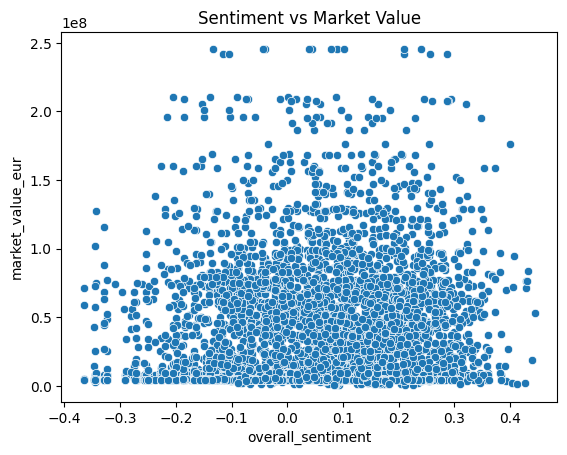

In [16]:
sns.scatterplot(x="overall_sentiment", y="market_value_eur", data=df)
plt.title("Sentiment vs Market Value")
plt.show()

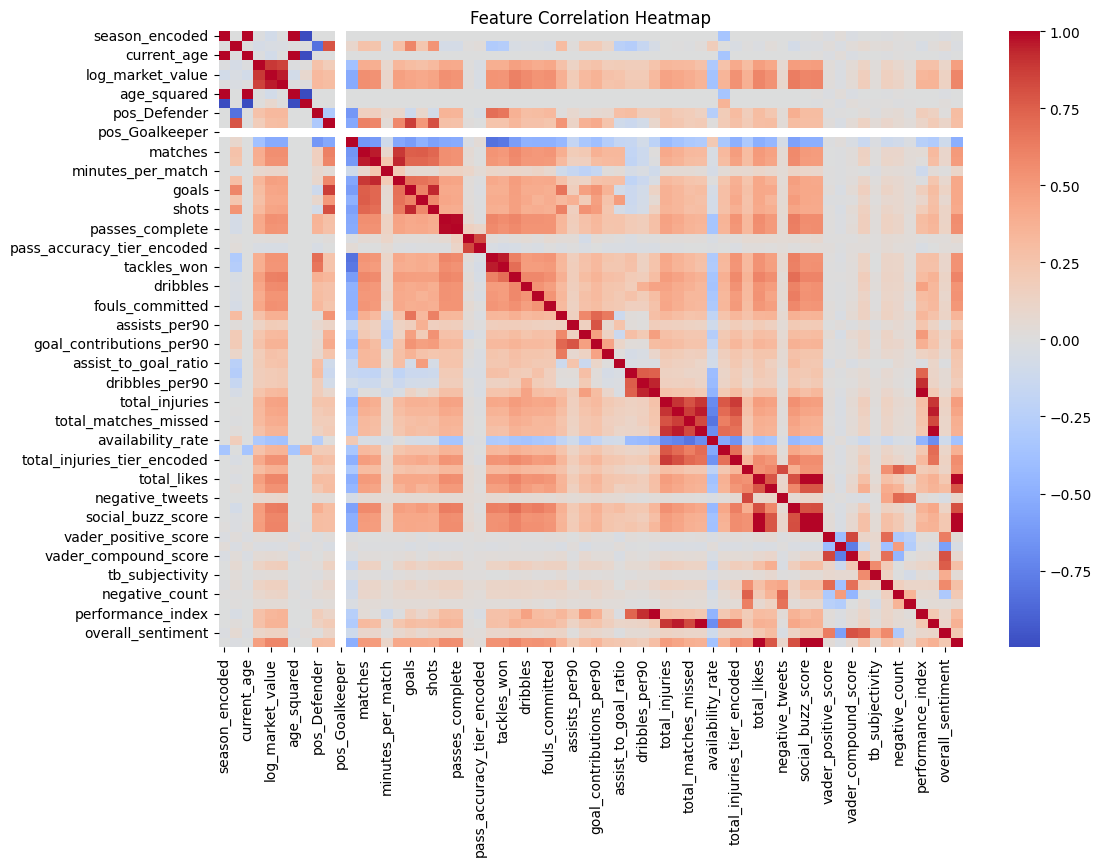

In [17]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [2]:
df = pd.read_csv("final_feature_dataset.csv")
df.head()

,player_name,season,season_encoded,team,position,position_encoded,current_age,market_value_eur,log_market_value,market_value_tier_encoded,...,tb_polarity,tb_subjectivity,positive_count,negative_count,neutral_count,sentiment_label,performance_index,injury_impact,overall_sentiment,popularity_index
0,Lionel AndrÃ©s Messi Cuccittini,2019/20,1,Barcelona,Forward,4,25,67500000,18.0276,4,...,0.1200,0.7767,2,1,0,Positive,3.137967,0.0,0.10605,0
1,Antoine Griezmann,2019/20,1,Barcelona,Forward,4,25,37500000,17.4399,3,...,0.3083,0.3833,0,2,1,Negative,1.440267,0.0,0.07865,0
2,Ousmane DembÃ©lÃ©,2019/20,1,Barcelona,Midfielder,3,25,19500000,16.7859,2,...,0.2944,0.5167,1,0,2,Positive,1.621700,0.0,0.25255,0
3,Anssumane Fati,2019/20,1,Barcelona,Midfielder,3,25,13500000,16.4182,2,...,-0.2333,0.0667,1,2,0,Negative,2.122967,0.0,-0.19300,0
4,Pedro GonzÃ¡lez LÃ³pez,2019/20,1,Barcelona,Defender,2,25,16500000,16.6189,2,...,0.2333,0.6593,1,2,0,Negative,0.593267,0.0,0.05005,0


In [3]:
data_uni = df[["market_value_eur"]]

In [4]:
scaler_uni = MinMaxScaler()
scaled_uni = scaler_uni.fit_transform(data_uni)

In [5]:
sequence_length = 3

X_uni = []
y_uni = []

for i in range(sequence_length, len(scaled_uni)):
    X_uni.append(scaled_uni[i-sequence_length:i])
    y_uni.append(scaled_uni[i])

X_uni = np.array(X_uni)
y_uni = np.array(y_uni)

In [6]:
X_train_uni, X_test_uni, y_train_uni, y_test_uni = train_test_split(
    X_uni, y_uni, test_size=0.2, shuffle=False
)

In [7]:
model_uni = Sequential()

model_uni.add(LSTM(50, input_shape=(X_train_uni.shape[1], 1)))
model_uni.add(Dense(1))

model_uni.compile(optimizer="adam", loss="mse")

C:\Users\Roshini\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
history_uni = model_uni.fit(
    X_train_uni,
    y_train_uni,
    epochs=30,
    batch_size=16,
    validation_data=(X_test_uni, y_test_uni)
)

Epoch 1/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0254 - val_loss: 0.0245
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0243 - val_loss: 0.0242
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0240 - val_loss: 0.0238
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0236 - val_loss: 0.0234
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0223 - val_loss: 0.0216
Epoch 6/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0218 - val_loss: 0.0212
Epoch 7/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0214 - val_loss: 0.0213
Epoch 8/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0212 - val_loss: 0.0206
Epoch 9/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0210 - val_loss: 0.0204
Epoch 10/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0207 - val_loss: 0.0206
Epoch 11/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0206 - val_loss: 0.0202
Epoch 12/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

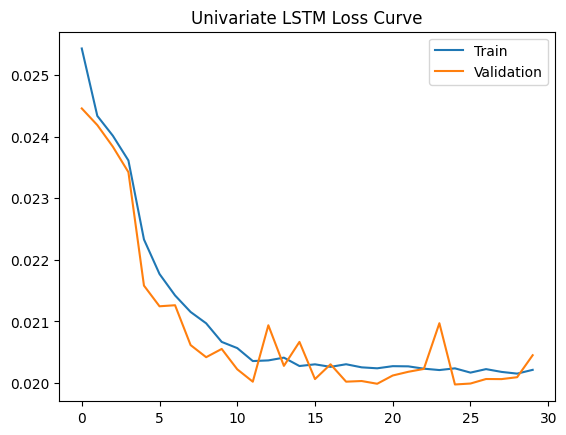

In [9]:
plt.plot(history_uni.history["loss"])
plt.plot(history_uni.history["val_loss"])
plt.title("Univariate LSTM Loss Curve")
plt.legend(["Train","Validation"])
plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


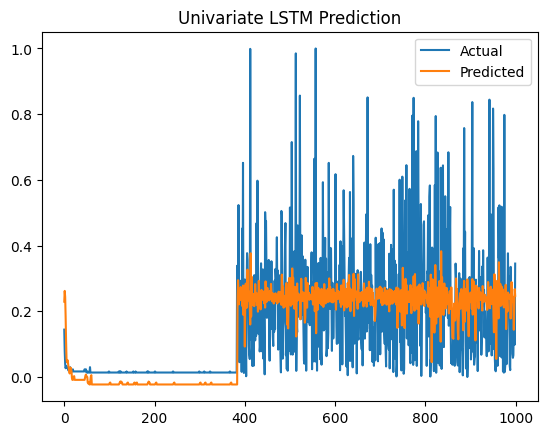

In [10]:
pred_uni = model_uni.predict(X_test_uni)

plt.plot(y_test_uni, label="Actual")
plt.plot(pred_uni, label="Predicted")
plt.title("Univariate LSTM Prediction")
plt.legend()
plt.show()

In [11]:
features = [
    "market_value_eur",
    "performance_index",
    "injury_burden_index",
    "availability_rate",
    "overall_sentiment"
]

data_multi = df[features]

In [12]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data_multi)

In [13]:
X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i][0])

X = np.array(X)
y = np.array(y)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [15]:
model = Sequential()

model.add(LSTM(50, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dense(1))

model.compile(optimizer="adam", loss="mse")

C:\Users\Roshini\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=16,
    validation_data=(X_test, y_test)
)

Epoch 1/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0240 - val_loss: 0.0229
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0228 - val_loss: 0.0222
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0220 - val_loss: 0.0214
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0210 - val_loss: 0.0221
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0207 - val_loss: 0.0204
Epoch 6/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0205 - val_loss: 0.0209
Epoch 7/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0204 - val_loss: 0.0204
Epoch 8/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0202 - val_loss: 0.0202
Epoch 9/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0201 - val_loss: 0.0198
Epoch 10/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0200 - val_loss: 0.0197
Epoch 11/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0200 - val_loss: 0.0199
Epoch 12/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

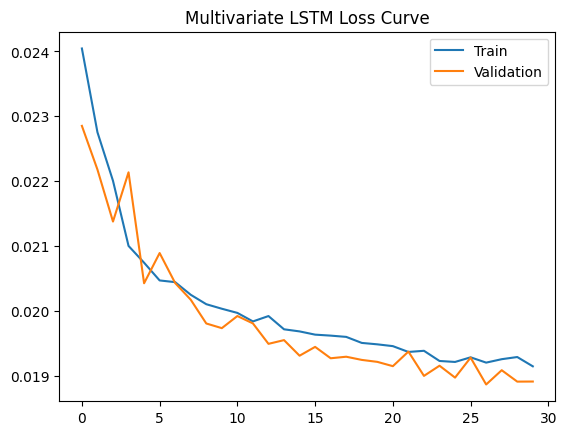

In [17]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Multivariate LSTM Loss Curve")
plt.legend(["Train","Validation"])
plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


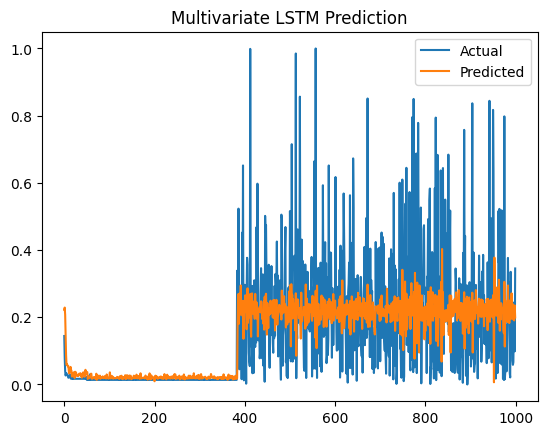

In [18]:
predictions = model.predict(X_test)

plt.plot(y_test, label="Actual")
plt.plot(predictions, label="Predicted")
plt.title("Multivariate LSTM Prediction")
plt.legend()
plt.show()

In [ ]:
Encoder-Decoder LSTM:
This sequence-to-sequence architecture can predict multiple future transfer windows.
It will be implemented in the next milestone as an extension of the current models.